In [1]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [3]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
print(df['Region'].unique())

<StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str


In [5]:
print(df['Category'].unique())
print(df['Segment'].unique())

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [6]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

print(df.dtypes)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [7]:
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [8]:
region_summary=df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales',ascending=False)
print(region_summary)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


In [9]:
category_summary=df.groupby('Category')[['Sales','Profit']].sum().sort_values('Profit',ascending=False)
print(category_summary)

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Office Supplies  719047.0320  122490.8008
Furniture        741999.7953   18451.2728


In [10]:
category_summary['Profit_Margin_%']=(category_summary['Profit']/category_summary['Sales']*100).round(2)
print(category_summary)

                       Sales       Profit  Profit_Margin_%
Category                                                  
Technology       836154.0330  145454.9481            17.40
Office Supplies  719047.0320  122490.8008            17.04
Furniture        741999.7953   18451.2728             2.49


In [11]:
discount_analysis=df.groupby('Category')[['Discount','Profit']].mean().round(3)
print(discount_analysis)

                 Discount  Profit
Category                         
Furniture           0.174   8.699
Office Supplies     0.157  20.327
Technology          0.132  78.752


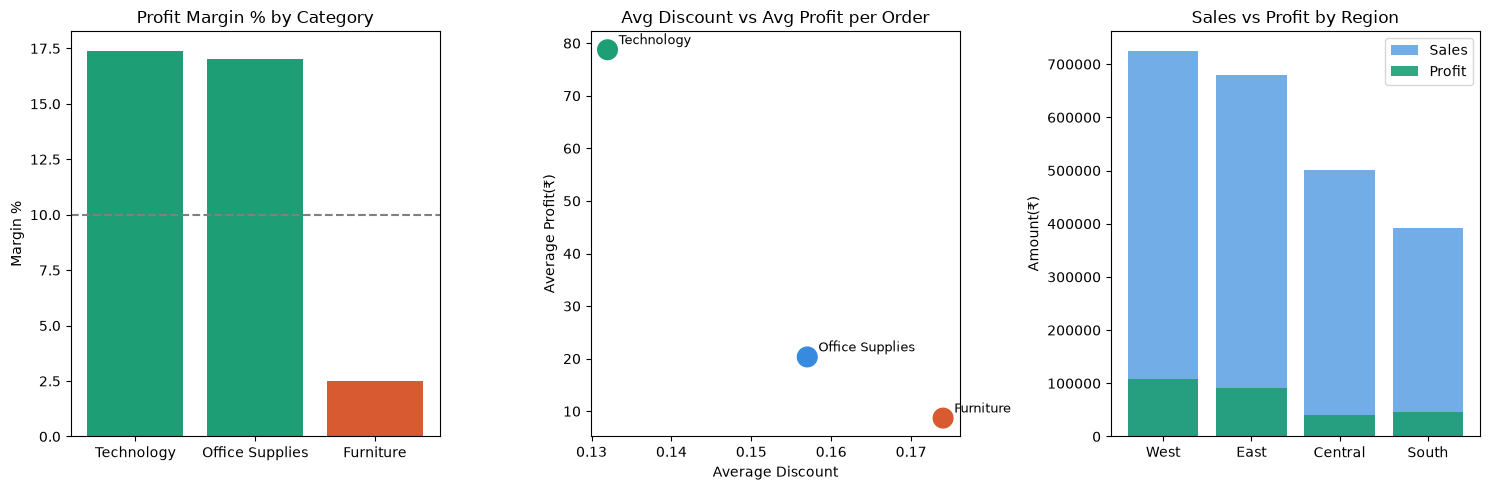

In [15]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,3,figsize=(15,5))

#chart-1 Profit Margin by Category
categories=category_summary.index
margins=category_summary['Profit_Margin_%']
colors=['#1D9E75' if m>10 else '#D85A30' for m in margins]

axes[0].bar(categories,margins,color=colors)
axes[0].set_title('Profit Margin % by Category')
axes[0].set_ylabel('Margin %')
axes[0].axhline(y=10,color='gray',linestyle='--',label='10% thresold')

#chart-2 Discount vs Profit scatter(per category)
disc=discount_analysis['Discount'].values
prof=discount_analysis['Profit'].values
cats=discount_analysis.index.tolist()

axes[1].scatter(disc,prof,s=200,color=['#D85A30','#378ADD','#1D9E75'])
for i, cat in enumerate(cats):
    axes[1].annotate(cat,(disc[i],prof[i]),
                     textcoords="offset points",xytext=(8,4),fontsize=9)
axes[1].set_title('Avg Discount vs Avg Profit per Order')
axes[1].set_xlabel('Average Discount')
axes[1].set_ylabel('Average Profit(₹)')

#chart-3 Sales vs Profit by Region
regions=region_summary.index
axes[2].bar(regions,region_summary['Sales'],label='Sales',color='#378ADD',alpha=0.7)
axes[2].bar(regions,region_summary['Profit'],label='Profit',color='#1D9E75',alpha=0.9)
axes[2].set_title('Sales vs Profit by Region')
axes[2].set_ylabel('Amount(₹)')
axes[2].legend()

plt.tight_layout()
plt.savefig('Superstore_insights.png',dpi=150)
plt.show()